## Pre-training:


- This Jupyter Notebook can be used to pre-train models for CPU/GPU or Akida using the config file or modifying specific config parameters in the first cell.

- Choose model_type, session type, used classes, etc...

- By running the whole jupyter notebook, the training and model saving will be done automatically.
    - Model performance is plotted, and the best model according to the specified metric in train_evaluate() will be saved in the local directory saved_models.
    - Models and csp objects will be saved as (LeftVsRight example): 
        - saved_models/LR_cpu.tf    and    cspLR_cpu.pkl    for CPU models
        - saved_models/LR.fbz       and    cspLR.pkl        for Akida models
        

In [1]:
from tensorflow import keras
import tensorflow as tf
from tensorflow.keras.losses import CategoricalCrossentropy


import numpy as np
import os, pickle, logging, warnings



from quantizeml.models import QuantizationParams, quantize
from cnn2snn import convert, set_akida_version, AkidaVersion


# Local imports
from network import CPU_NetCNN2D_CSP, Akida_HWOnly_NetCNN2D_CSP, build_functional_cnn2D
import dataset
from config import Config
import train_evaluate






# Filter out unneeded info and warnings from TensorFlow
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
logging.getLogger('tensorflow').setLevel(logging.ERROR)
warnings.filterwarnings('ignore')





config = Config()

config.model_type = 'cpu'

config.used_classes = [['CUp'], ['CDown']]  #[['CLeft', 'CRight'], ['CUp', 'CDown']]
config.session_type = 'S2'

config.test_session = 11

if config.model_type == 'akida':
    config.window_size = 1.0
elif config.model_type == 'cpu':
    config.window_size = 2.0


################# Training parameters #################

config.stride = 1.0 #0.5

config.epochs = 5#200
config.batch_size = 64#32

config.learning_rate = 1e-4
config.label_smoothing = 0.05 
config.weight_decay = 1e-5

In [2]:
# This cell gets data for training and validation for chosen train/valid split.a

X, y = [], []
for i in range(1, 12):
    if i == config.test_session:
        continue
    Xi, yi = dataset.session_dataset(config, f'I{i:02d}')
    X.append(Xi)
    y.append(yi)


X, y = np.concatenate(X), np.concatenate(y)


shuffle_indices = np.random.permutation(len(y))
X_train, Y_train = X[shuffle_indices], y[shuffle_indices]


X, y = dataset.session_dataset(config, f'I{config.test_session:02d}')
shuffle_indices = np.random.permutation(len(y))
X_valid, Y_valid = X[shuffle_indices], y[shuffle_indices]


# X shape = (N, Channels, Time) example: (320, 13, 500)
# Y shape = (N,) example (320,)

print("Training data size before slicing:   ", len(Y_train))
print("Validation data size before slicing: ", len(Y_valid))

Training data size before slicing:    320
Validation data size before slicing:  37


Epoch 1/5
10/10 [==============================] - 5s 323ms/step - loss: 0.6901 - acc: 0.4875 - val_loss: 0.6972 - val_acc: 0.5676
Epoch 2/5
10/10 [==============================] - 0s 16ms/step - loss: 0.6890 - acc: 0.5188 - val_loss: 0.6979 - val_acc: 0.5541
Epoch 3/5
10/10 [==============================] - 3s 282ms/step - loss: 0.6865 - acc: 0.5437 - val_loss: 0.6987 - val_acc: 0.5946
Epoch 4/5
10/10 [==============================] - 0s 14ms/step - loss: 0.6892 - acc: 0.5437 - val_loss: 0.6992 - val_acc: 0.5811
Epoch 5/5
10/10 [==============================] - 0s 13ms/step - loss: 0.6873 - acc: 0.5344 - val_loss: 0.6995 - val_acc: 0.5135


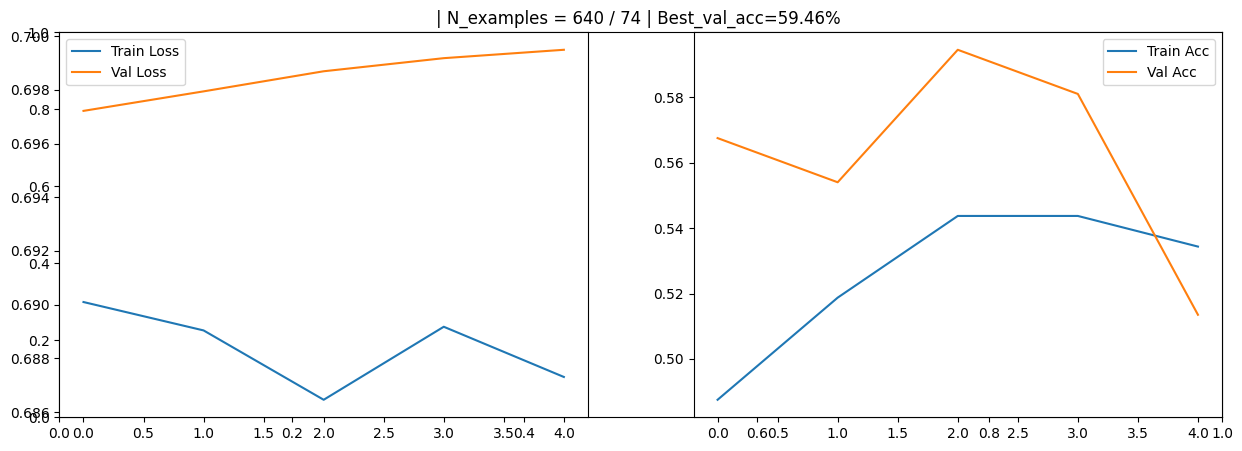

Best model saved  with validation accuracy: 0.5946


In [3]:
# This cell instanciates and train models depending on model_type
# then saves returned best model and csp object to save (cpu model) or use later (akida model)


if config.model_type == 'akida':
    model = Akida_HWOnly_NetCNN2D_CSP(len(config.used_classes))

    model, csp, val_acc = train_evaluate.train_evalute(config, X_train, Y_train, X_valid, Y_valid, model, choose_on='acc', plot_graphs=True)


elif config.model_type == 'cpu':
    model = CPU_NetCNN2D_CSP(len(config.used_classes))

    model, csp, val_acc = train_evaluate.train_evalute(config, X_train, Y_train, X_valid, Y_valid, model, choose_on='val_acc', plot_graphs=True)

    # naming exemple: 'LR_cpu'  if left and right classes are selected
    naming = config.used_classes[0][0][1] + config.used_classes[1][0][1] + '_cpu'

    model.save(os.path.join('saved_models', naming+'.tf'), save_format='tf')
    print(f"Best model saved  with validation accuracy: {val_acc:.4f}")

    with open(os.path.join('saved_models','csp'+naming+'.pkl'), 'wb') as f:
        pickle.dump(csp, f)

In [4]:
# If model_type == 'akida',  the model is quantized first using QuantizeML then converted to an akida model using cnn2snn 

if config.model_type == 'akida':

    # Obtain sliced data depending on windows size and stride (will be used for calibration and evaluation of Quantized model)
    X_train, _ = dataset.slice_EEG_epoch(config, X_train, Y_train)           # X_train shape = (N, Channels/Electrodes, Time)
    X_valid, Y_valid = dataset.slice_EEG_epoch(config, X_valid, Y_valid)     # X_valid shape = (N, Channels/Electrodes, Time), Y_valid shape = (N,)

    # Use Pre-training CSP to transform data
    X_train = csp.transform(X_train)    # X_train shape = (N, CSP_components, Time)
    X_valid = csp.transform(X_valid)    # X_train shape = (N, CSP_components, Time)

    
    # Expand dims for CNN2D (N, H, W, C)
    X_train = np.expand_dims(X_train, 3)    # X_train shape = (N, CSP_components, Time, 1)
    X_valid = np.expand_dims(X_valid, 3)    # X_train shape = (N, CSP_components, Time, 1)


    # convert Y_valid to one-hot format
    Y_valid = tf.keras.utils.to_categorical(Y_valid, num_classes = len(config.used_classes)) # Y_valid shape = (N, n_classes) example (N, 2)



    # Quantize to uint8 ([0, 255]) data linearly (see README for more details about this)
    Xq = ((X_train - X_train.min()) / (X_train.max() - X_train.min()) * 255).astype(np.uint8)
    Xqv = ((X_valid - X_valid.min()) / (X_valid.max() - X_valid.min()) * 255).astype(np.uint8)


    # Zero-padding for the csp_components dimension to be compatible with akida's kernel_size constraints (see README for more details about this)
    Xq = np.pad(Xq, ((0, 0), (2, 2), (0, 0), (0, 0)), mode='constant', constant_values=0)
    Xqv = np.pad(Xqv,  ((0, 0), (2, 2), (0, 0), (0, 0)), mode='constant', constant_values=0)


    # building the functional model and loading the saved pre-training weights
    functional_model = build_functional_cnn2D(n_classes=2, input_shape=(7, 250, 1))
    functional_model.set_weights(model.get_weights())


    # Quantization of the model using QuantizeML:
    # 844 Quantization params which is compatible with version 1 Akida, inputs are 8 bits, while weights and activations are 4 bits
    # Using 300 samples from Xq to calibrate the quantized model (see meta-tf/akida documentation website) 
    qparams = QuantizationParams(input_weight_bits=8, weight_bits=4, activation_bits=4, per_tensor_activations=True)
    quantized_model = quantize(functional_model, qparams=qparams, samples=Xq, num_samples=300, batch_size=64, epochs=10)
    quantized_model.summary()



    quantized_model.compile(
            loss= CategoricalCrossentropy(from_logits=True, label_smoothing=config.label_smoothing),
            optimizer=keras.optimizers.Adam(learning_rate=config.learning_rate, weight_decay = config.weight_decay), 
            metrics=[keras.metrics.CategoricalAccuracy(name='acc')]
    ) 



    # Evaluate quantized model on validation data
    loss, acc = quantized_model.evaluate(Xqv, Y_valid)



    # Convert the Quantized model to a V1 akida model using the cnn2snn package 

    with set_akida_version(AkidaVersion.v1):
        model_akida = convert(quantized_model)
        model_akida.summary()



    # Save akida model using self.save and the csp object using pickle

    naming = config.used_classes[0][0][1] + config.used_classes[1][0][1]

    model.save(os.path.join('saved_models',naming+'.tf'), save_format='tf')

    with open(os.path.join('saved_models','csp' +naming+ '.pkl'), 'wb') as f:
        pickle.dump(csp, f)

    model_akida.save(os.path.join('saved_models', naming+'.fbz'))




    print("\n\n\n ====================================================")
    print("Quantized model validation acc = ", acc)
    print("====================================================")